In [12]:
import pandas as pd
enron = pd.read_csv('../data/enron_model_ft.csv')

/var/folders/4y/0t9f134178bbfj5m299wl_7h0000gn/T/ipykernel_26151/2732611547.py:2: DtypeWarning: Columns (2,4,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  enron = pd.read_csv('../data/enron_model_ft.csv')


In [13]:
def bucket_urgency(minutes):
    if pd.isna(minutes):
        return 'ghosted'
    elif minutes < 5:
        return 'instant'
    elif minutes < 15:
        return 'fast'
    elif minutes < 24*60:
        return 'same_day'
    else:
        return 'next_day'

enron['urgency_bucket'] = enron['response_time'].apply(bucket_urgency)

In [14]:
enron_valid = enron[enron['response_time'] >= 0]

sender_speed = (
    enron_valid
    .groupby('From')['response_time']
    .agg(avg_response='mean', n_replies='count')
    .query('n_replies >= 5')
    .sort_values('avg_response')
)

fastest_responders = sender_speed.head(20)

In [15]:
fastest_responders

,avg_response,n_replies
From,,
"Maggi, Mike",1.851064,47
ted.evans@enron.com,2.600000,5
"Rybarski, Amanda",4.000000,10
chance.rabon@enron.com,5.200000,5
tom.moran@enron.com,6.200000,5
mjillard@beaconelectric.com,8.714286,7
davis.thames@enron.com,9.666667,6
john.knock@elpaso.com,10.000000,5
llmaser@degeurinrealty.com,10.000000,5


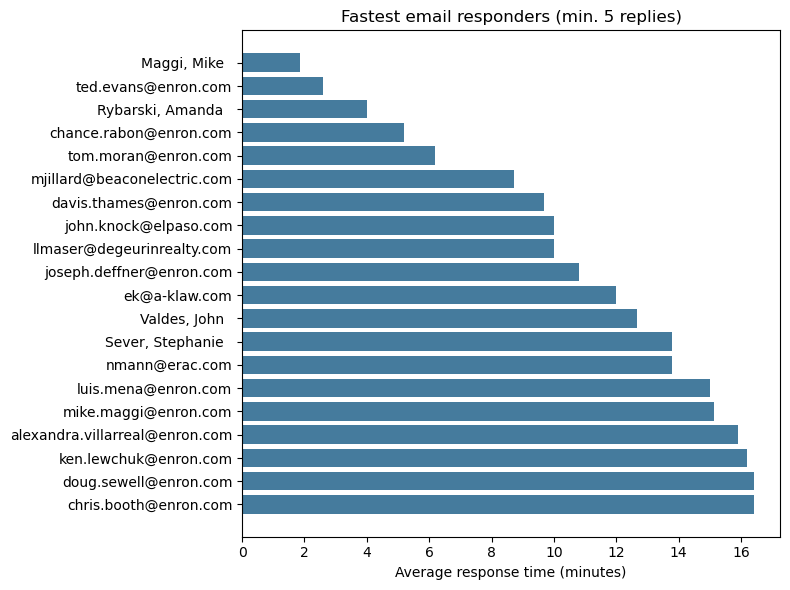

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
data = fastest_responders.sort_values('avg_response', ascending=True)
bars = ax.barh(data.index, data['avg_response'], color='#457b9d')
ax.set_xlabel('Average response time (minutes)')
ax.set_title('Fastest email responders (min. 5 replies)')
ax.invert_yaxis()  # fastest on top
plt.tight_layout()
plt.show()

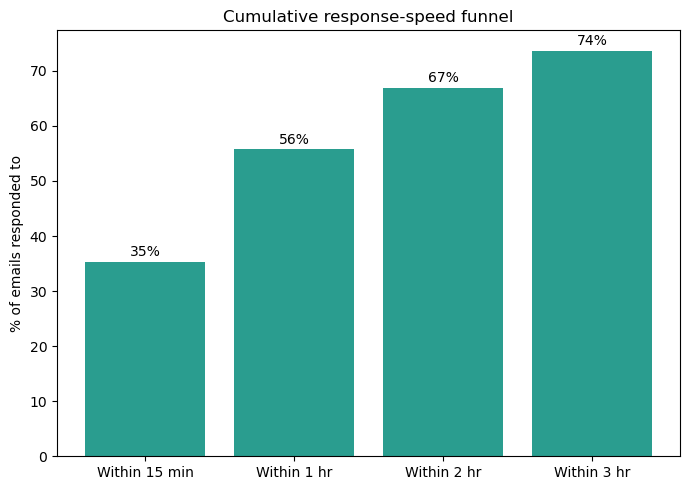

In [20]:
thresholds = ['Response_Within_15_Mins', 'Response_Within_60_Mins', 'Response_Within_120_Mins', 'Response_Within_3_hours']
labels = ['Within 15 min', 'Within 1 hr', 'Within 2 hr', 'Within 3 hr']
pcts = [enron_valid[t].mean() * 100 for t in thresholds]

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(labels, pcts, color='#2a9d8f')
ax.set_ylabel('% of emails responded to')
ax.set_title('Cumulative response-speed funnel')
for i, p in enumerate(pcts):
    ax.text(i, p + 1, f'{p:.0f}%', ha='center')
plt.tight_layout()
plt.show()